#Download data

In [236]:
# to get the data
#!pip install yfinance
#!pip install lxml

In [237]:
import pandas as pd
import numpy as np
import yfinance as yf
import requests
from io import StringIO
import math
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import *
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import keras


In [238]:
# get labels from wikipedia
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}
html = requests.get(url, headers=headers, timeout=20)
html.raise_for_status()
sp500_df = pd.read_html(StringIO(html.text))[0]
tickers = sp500_df["Symbol"].str.replace(".", "-", regex=False).tolist() # for some reason there are 503 labels, figure out why!!!
tickers.insert(0,'^GSPC') # add S&P500 index, which we try to predict

# Download all S&P 500 data given the previous labels
#data = yf.download(tickers=tickers,start="2015-01-01",end="2023-01-01",group_by='ticker',threads=True)

# just keep opening prices
open_prices = pd.concat({ticker: data[ticker]["Close"] for ticker in data.columns.levels[0]},axis=1)

# remove firms with nan-values, remove around 50 firms
open_prices_interp = open_prices.interpolate(method='linear', axis=0, limit=1) # if nan-values at one point then average between before and after, for instance, if uneven opening days for some reason
open_prices_interp = open_prices_interp.dropna(axis=1) # this should drop columns containing nan-values

# remove firms without sector or industry information for graphs, only removes 1 firm
tickers_with_data = list(open_prices_interp.columns)
firm_industry_dict = {}
removed_labels = []
for firm in tickers_with_data:  # slow as fuck, but it works
  info = yf.Ticker(firm).info
  try:
    firm_industry_dict[firm]= (info["sector"], info["industry"])
  except:
    print(firm)
    if not firm == '^GSPC': #of course no sector and industry information for S&P500
      removed_labels.append(firm)
      tickers_with_data.remove(firm) # missing sector or industry information about this firm, so remove it

# quick fix, i had a problem with this firm
tickers_with_data.remove('FITB')
removed_labels.append('FITB')

# remove firms without graph data
open_prices_interp = open_prices_interp.drop(columns=removed_labels)

# into numpy
x = open_prices_interp.to_numpy() #

FISV
^GSPC


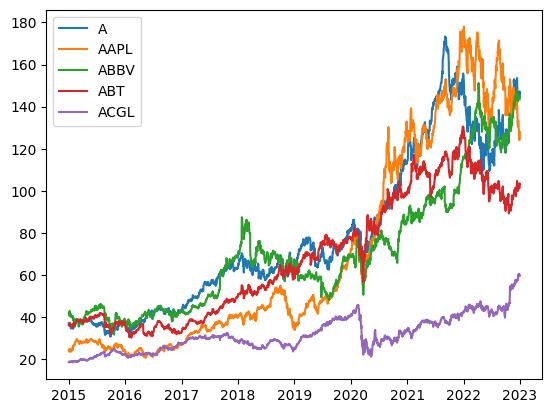

In [ ]:
# just to get a visualization that it looks right
for i in open_prices_interp.columns[:5]:
  prices = open_prices_interp[i]
  plt.plot(prices.index, prices.values, label=f'{i}')
plt.legend()

In [ ]:
# what do we do with those companies not on the stock exchange the entire time? Nan values, like the one below?
# I have dropped companies that contained nan values, because they were annoying. I think these companies that later joined the S&P500 and were not not a part of the stock exchange at that time
#open_prices['ABNB']

In [ ]:
sum(np.isnan(x))

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
set_of_sector = set()
set_of_industry = set()
for val in firm_industry_dict.values():
  sector, industry = val
  set_of_sector.add(sector)
  set_of_industry.add(industry)

# make adjacency matrix
firm_tickers = tickers_with_data[:-1] # avoid '^GSPC', which is the first for the tickers
N = len(firm_tickers)
A = np.zeros((N, N, 2)) # 2 types of relation, industry and sector

for i, ti in enumerate(firm_tickers):
    for j, tj in enumerate(firm_tickers):
        if ti == tj:
            continue
        if firm_industry_dict[ti][1] == firm_industry_dict[tj][1]:
            A[i, j, 0] = 1   # connection type 1
        elif firm_industry_dict[ti][0] == firm_industry_dict[tj][0]:
            A[i, j, 1] = 1   # connection type 2

# RQ1
## Prepare data for LSTM

In [ ]:
# Make data more stationary by using log and diff, so we get the relative changes  (I thought that an LSTM model could predict non-stationary time-series, but it was a bit tough for it)
x_returns = np.diff(np.log(x),axis=0)

# create moving average features, what they do in the paper
windows = [5, 10, 20, 30]

def moving_average(a, window):
    return np.apply_along_axis(lambda x: np.convolve(x, np.ones(window)/window, mode='valid'), axis=0, arr=a)

ma_dict = {w: moving_average(x_returns, w) for w in windows}
min_T = min(ma.shape[0] for ma in ma_dict.values())
x_trim = x_returns[-min_T:]
ma_trimmed = [ma_dict[w][-min_T:] for w in windows]
features = np.stack([x_trim] + ma_trimmed, axis=-1)

f'(Time point, firm, type of price)= {features.shape}' # the last in the second dimension is S&P500

'(Time point, firm, type of price)= (1984, 461, 5)'

## Create training, validation and test data

In [ ]:
# target only first
target = features[:, -1, 0] # only the S&P 500

n = len(target)
train_end = n // 2
val_end = train_end + n // 4

train_raw = features[:train_end,:,:]
val_raw   = features[train_end:val_end,:,:]
test_raw  = features[val_end:,:, :]

# Get original shapes for reshaping back
train_shape = train_raw.shape
val_shape = val_raw.shape
test_shape = test_raw.shape

# Reshape 3D data to 2D for StandardScaler (combine first two dimensions)
# This treats each (time_point, firm) as a sample, and the 'type of price' as features
train_reshaped = train_raw.reshape(-1, train_shape[-1])
val_reshaped = val_raw.reshape(-1, val_shape[-1])
test_reshaped = test_raw.reshape(-1, test_shape[-1])

sc = StandardScaler()
train_scaled_reshaped = sc.fit_transform(train_reshaped)
val_scaled_reshaped   = sc.transform(val_reshaped)
test_scaled_reshaped  = sc.transform(test_reshaped)

# Reshape back to 3D after scaling
train_scaled = train_scaled_reshaped.reshape(train_shape)
val_scaled   = val_scaled_reshaped.reshape(val_shape)
test_scaled  = test_scaled_reshaped.reshape(test_shape)

# Concatenate along the time dimension (axis=0)
full_scaled = np.concatenate((train_scaled, val_scaled, test_scaled), axis=0)

seq_len = 8 # What they do

X, y = [], []
for i in range(seq_len, len(full_scaled)):
    X.append(full_scaled[i-seq_len:i, :,:])
    y.append(full_scaled[i, -1, 0]) # Corrected target slicing to get the S&P 500 value

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

train_idx = train_end - seq_len
val_idx   = val_end - seq_len

X_train, y_train = X[:train_idx], y[:train_idx]
X_val,   y_val   = X[train_idx:val_idx], y[train_idx:val_idx]
X_test,  y_test  = X[val_idx:], y[val_idx:]

## the LSTM model

In [ ]:
output_dim = 1 # y.shape[1]
units =  32 # what they use in the paper X.shape[2]
input_dim = X_train.shape[1:3]

model = Sequential()
model.add(LSTM(units = units, return_sequences = True, input_shape = input_dim))
model.add(Dropout(0.2))
model.add(LSTM(units = units*2, return_sequences = False))
model.add(Dropout(0.2))
model.add(Dense(units = output_dim))

es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)

model.compile(optimizer = 'adam', loss = 'mean_squared_error')  # use mean_squared_error when regression problem
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 8, 32)          │        63,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,129 (344.25 KB)

 Trainable params: 88,129 (344.25 KB)

 Non-trainable params: 0 (0.00 B)

In [227]:
history_es = model.fit(X_train[:,:,:,0], y_train, epochs=100, validation_data=(X_val[:,:,:,0],y_val), callbacks=[es], shuffle=False)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.2550 - val_loss: 0.9733
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2232 - val_loss: 1.0070
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1971 - val_loss: 1.0663
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1944 - val_loss: 0.9840
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.2086 - val_loss: 0.9944
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1741 - val_loss: 1.0011
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1474 - val_loss: 1.0229
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1372 - val_loss: 1.0254
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1359 - val_loss: 1.0359
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1212 - val_loss: 1.0780
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1030 - val_loss: 1.0570


In [232]:
pred_scaled = model.predict(X_test[:, :, 0:1,0])
# Manually inverse transform pred_scaled to undo the scaling
pred = pred_scaled * sc.scale_[0] + sc.mean_[0]
real = y_test * sc.scale_[0] + sc.mean_[0]

max_left_from_ma = max(windows)//2-1
start_date_for_plot = 1 + max_left_from_ma + (val_idx + seq_len)
dates = open_prices_interp.index[start_date_for_plot : start_date_for_plot + len(y_test)]

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


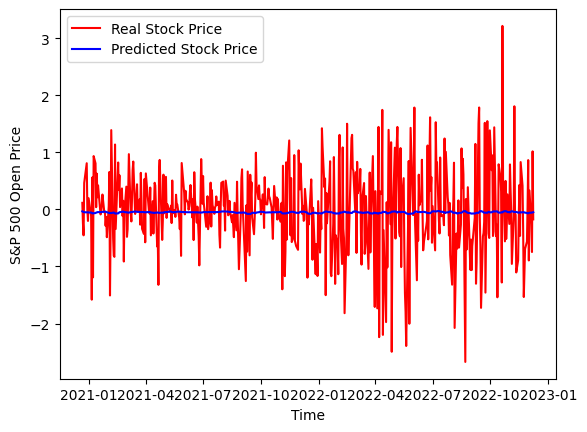

In [233]:
plt.plot(dates, y_test, color='red', label='Real Stock Price')
plt.plot(dates, pred_scaled, color='blue', label='Predicted Stock Price')
plt.xlabel('Time')
plt.ylabel('S&P 500 Open Price')
plt.legend()
plt.show()

In [234]:
# It is better to just go with the average hahahh
print(np.mean(y_test[:,np.newaxis]-np.mean(y_train)))
print(np.mean(y_test[:,np.newaxis]-pred_scaled))
sign_real = y_test>0
sign_pred = pred_scaled>0
print(f'Share for predicting right direction{sum(sign_pred == sign_real[:,np.newaxis])/len(sign_pred)}')

-0.012479032
0.031927947
Share for predicting right direction[0.5141129]


# TGC